In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

# Importation de ton module propriétaire
from backtest_engine import run_vectorized_backtest

# Style graphique épuré
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
# Téléchargement des données via l'API yfinance
ticker = "AAPL"
data = yf.download(ticker, start="2016-01-01", end="2026-01-01")

# Nettoyage pour s'assurer qu'on travaille avec des Series 1D propres
prices = data["Close"].squeeze()

print(f"Données récupérées pour {ticker} : {len(prices)} jours de trading.")
prices.head()

[*********************100%***********************]  1 of 1 completed

Données récupérées pour AAPL : 2514 jours de trading.


Date
2016-01-04    23.709103
2016-01-05    23.114969
2016-01-06    22.662613
2016-01-07    21.706152
2016-01-08    21.820925
Name: AAPL, dtype: float64

In [3]:
# 1. Calcul des indicateurs (Moyennes Mobiles Courte 20 / Longue 50)
sma_short = prices.rolling(window=20).mean()
sma_long = prices.rolling(window=50).mean()

# 2. Génération des signaux vectorisés
signals = pd.Series(np.where(sma_short > sma_long, 1, 0), index=prices.index)
signals.iloc[:50] = 0  # Nettoyage des NaN du début

# 3. Exécution des deux backtests
costs_per_trade = 0.0010  # 0.10% de frais (frais de courtage + slippage)

results_perfect = run_vectorized_backtest(prices, signals, transaction_costs=0.0)
results_realistic = run_vectorized_backtest(prices, signals, transaction_costs=costs_per_trade)

# Affichage du rapport comparatif
print("=" * 50)
print(f"📊 FRICTION IMPACT ANALYSIS FOR {ticker}")
print("=" * 50)
print(f"Total Trades Executed : {results_realistic['total_trades']}")
print("-" * 50)
print(f"Perfect Return (0% TC) : {results_perfect['total_return'] * 100:.2f}% (Sharpe: {results_perfect['sharpe_ratio']:.2f})")
print(f"Real Return (0.1% TC)  : {results_realistic['total_return'] * 100:.2f}% (Sharpe: {results_realistic['sharpe_ratio']:.2f})")
print("=" * 50)

📊 FRICTION IMPACT ANALYSIS FOR AAPL
Total Trades Executed : 57
--------------------------------------------------
Perfect Return (0% TC) : 306.49% (Sharpe: 0.75)
Real Return (0.1% TC)  : 283.97% (Sharpe: 0.72)


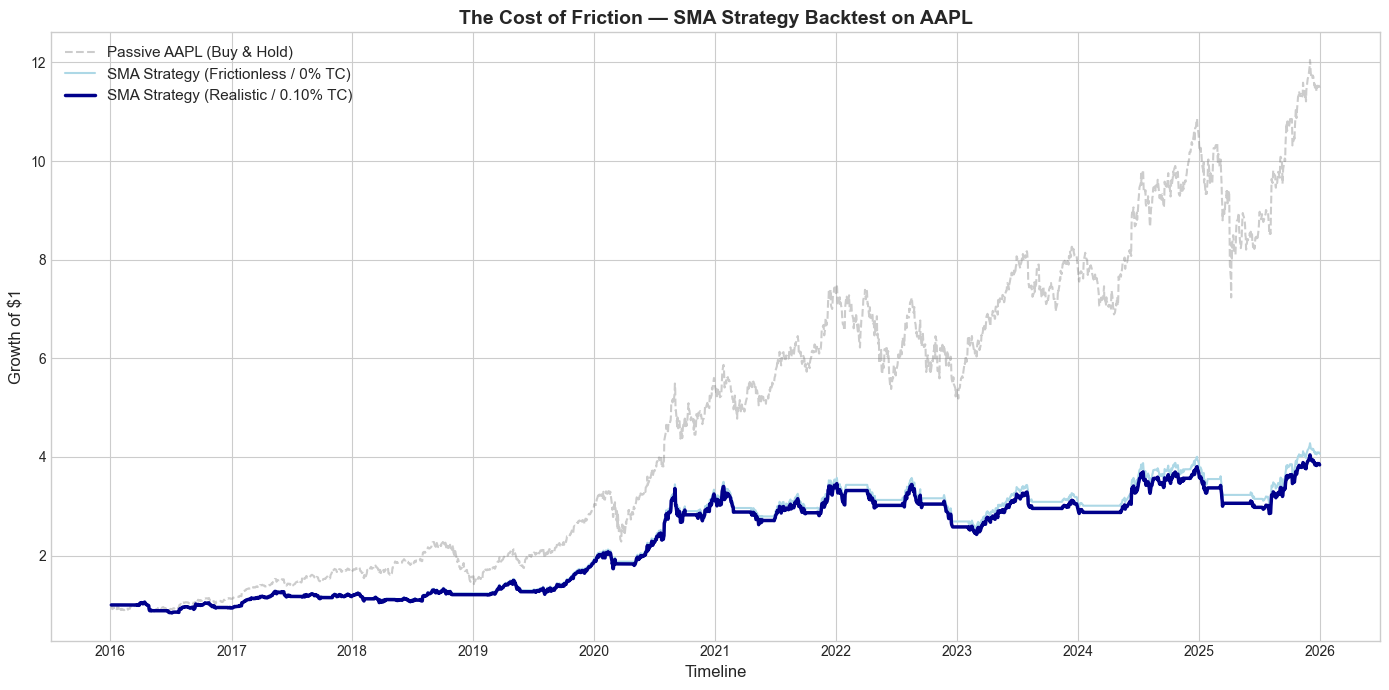

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# 1. Benchmark Passif (Buy & Hold)
plt.plot(
    results_perfect["asset_equity"],
    label=f"Passive {ticker} (Buy & Hold)",
    color="gray",
    alpha=0.4,
    linestyle="--",
)

# 2. Stratégie théorique (Sans frais)
plt.plot(
    results_perfect["strategy_equity"],
    label="SMA Strategy (Frictionless / 0% TC)",
    color="lightblue",
    linewidth=1.5,
)

# 3. Stratégie réelle (Avec frais)
plt.plot(
    results_realistic["strategy_equity"],
    label="SMA Strategy (Realistic / 0.10% TC)",
    color="darkblue",
    linewidth=2.5,
)

plt.title(f"The Cost of Friction — SMA Strategy Backtest on {ticker}", fontsize=14, fontweight="bold")
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Growth of $1", fontsize=12)
plt.legend(fontsize=11, loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
" Remarques "

# 1. La Réalité des Frictions :
# --> L'introduction de frais de transaction à hauteur de 10 bps (0.10%) permet de casser le mythe du backtest "parfait". 
# --> L'écart entre la courbe claire (théorique) et la courbe foncée (réelle) illustre le coût de l'implémentation d'une stratégie sur les marchés.


# 2. L'impact du Turn-Over : Plus une stratégie génère de signaux (frais de rotation ou turn-over élevé), plus elle est sensible aux coûts de transaction. 
# --> Si le Ratio de Sharpe s'effondre trop lourdement après intégration des coûts, cela signifie que la fréquence de trading est trop élevée pour la rentabilité du signal.


# 3. Optimisation Mathématique :
# --> L'implémentation de la détection des transactions s'effectue vectoriellement via l'opération `signals.diff().abs()`
# --> Préserve la vitesse d'exécution algorithmique sur de grands ensembles de données sans recourir à des boucles de contrôle de flux de bas niveau.

In [ ]:
" Leçons de Quant à retenir "

# 1. L'écart cumulé : 
# --> Au début (2016-2020), la courbe bleu clair (0% TC) et la courbe bleu foncé (0.10% TC) sont presque confondues. 
# --> Plus le temps passe, plus l’écart se creuse. C’est l’effet dévastateur de la capitalisation des frais de transaction. 
# --> Chaque trade grignote un petit bout du capital qui ne pourra plus fructifier le lendemain.

# 2. Le "Buy & Hold" bat la stratégie : 
# --> Sur Apple (AAPL), une simple stratégie de Moyennes Mobiles fait moins bien qu’un investissement passif (la courbe en pointillés gris). 
# Pourquoi ? Parce qu’Apple a connu un marché haussier (bull market) surpuissant sur cette décennie. 
# Dans un gros marché haussier, rester assis sur ses actions bat presque toujours une stratégie qui passe son temps à entrer et sortir du marché (et qui rate souvent le début des grosses hausses).